In [17]:
import os
import glob
import numpy as np
import pandas as pd
import scienceplots
import matplotlib.pyplot as plt

# plt.style.use(['science', 'ieee'])

In [18]:
# 相对误差
def mean_relative_error(y_true, y_pred,):
    relative_error = np.average(np.abs(y_true - y_pred) / y_true, axis=0)
    return relative_error

In [19]:
def get_targets(root):
    paths = glob.glob(os.path.join(root, '*.csv'))
    sohs = []
    
    for path in paths:
        data = pd.read_csv(path)
        target = data['SOH']
        sohs.append(target)

    sohs = np.concatenate(sohs)
    return sohs

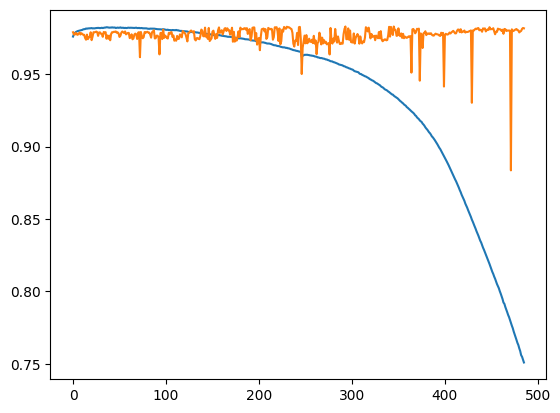

In [20]:
root = '../../data/soh_task1_Baseline_tri_pseudo_policy6C(31%)-4.25C_id44_cl462_task1_0'
preds = np.load(os.path.join(root, 'pred.npy'))
labels = np.load(os.path.join(root, 'true.npy'))

plt.plot(labels)
plt.plot(preds)

[  3.   2.   3.   2.   2.   3.   2.   3.   3.   2.   2.   3.   3.   3.
   2.   3.   3.   3.   3.   3.   3.   2.   3.   3.   3.   3.   3.   4.
   3.   4.   3.   4.   5.   5.   5.   6.   6.   8.   8.   9.   9.  11.
  12.  15.  19.  31.  19.  31.  54. 142.] [0.75095922 0.75558805 0.76021683 0.76484567 0.76947451 0.77410328
 0.77873212 0.7833609  0.78798974 0.79261857 0.79724735 0.80187619
 0.80650502 0.8111338  0.81576264 0.82039148 0.82502025 0.82964909
 0.83427793 0.83890671 0.84353554 0.84816432 0.85279316 0.85742199
 0.86205077 0.86667961 0.87130845 0.87593722 0.88056606 0.8851949
 0.88982368 0.89445251 0.89908129 0.90371013 0.90833896 0.91296774
 0.91759658 0.92222542 0.92685419 0.93148303 0.93611187 0.94074064
 0.94536948 0.94999832 0.9546271  0.95925593 0.96388471 0.96851355
 0.97314239 0.97777116 0.9824    ] <BarContainer object of 50 artists>
50 51 50


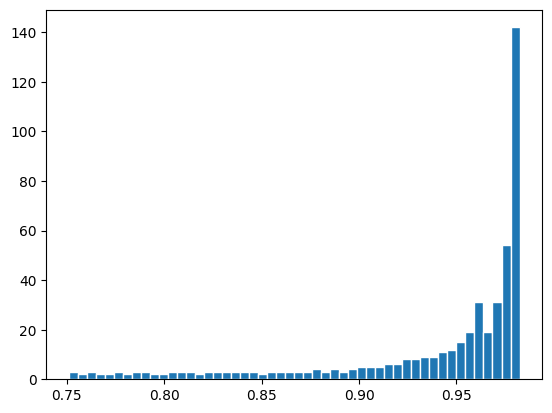

In [21]:
n, bins, patches = plt.hist(labels, bins=50, edgecolor='white')
print(n, bins, patches)
print(len(n), len(bins), len(patches))

In [22]:
df_res = pd.DataFrame({'idx': list(range(1, len(preds) + 1)),'preds': preds, 'labels': labels, 'seg': [-1] * len(preds)}, index=None)
df_res['err'] = mean_relative_error(df_res['labels'], df_res['preds'])
# df_res['err'] = abs(df_res['labels'] - df_res['preds'])

In [23]:
for i in range(len(bins) - 1):
    lower, upper = bins[i], bins[i+1]
    for idx in df_res.index:
        if lower <= df_res.loc[idx, 'labels'] <= upper:
            df_res.loc[idx, 'seg'] = i

50 50


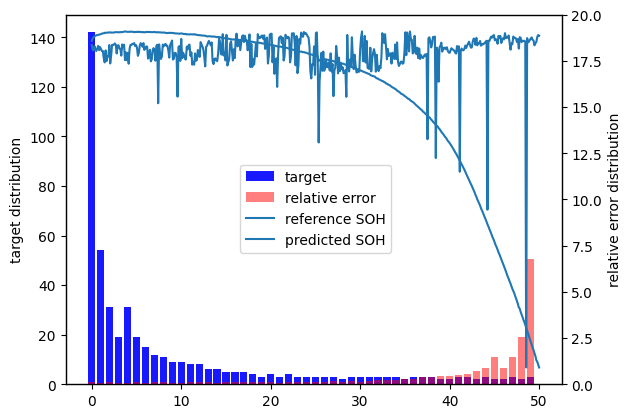

In [24]:
df_err = df_res.groupby('seg').sum()
df_err['err'] = df_err['err']
# print(df_err)

fig = plt.figure()
ax1 = fig.add_subplot(111)
# ax1.hist(labels, bins=50, edgecolor='white', label='target')
# ax1.set_xlim([0.7, 1])
ax1.bar(list(range(len(n))), n[::-1], color='blue', alpha=0.9, label='target')
ax1.set_ylabel('target distribution')
ax2 = ax1.twinx()  # this is the important function
# ax2_idx = np.linspace(0.7, 1, len(df_err))
ax2.bar(list(range(len(df_err))), df_err['err'].values, color='red', alpha=0.5, label='relative error')
ax2.set_ylim([0, 20])
ax2.set_ylabel('relative error distribution')

print(len(df_err), len(n))
# 保存list(range(len(n))), n[::-1]和df_err['err'].values的值到csv文件
df_hist = pd.DataFrame({'idx': list(range(len(n))), 'target_distribution': n[::-1], 'relative_error_distribution': df_err['err'].values})
df_hist.to_csv('histogram_data.csv', index=False)

ax3 = ax1.twinx()
ax34_idx = np.linspace(0, 50, len(preds))
ax3.plot(ax34_idx, labels, label='reference SOH')
ax4 = ax1.twinx()
ax4.plot(ax34_idx, preds, label='predicted SOH')

# 保存ax34_idx和labels、preds的值到csv文件
df_ax34 = pd.DataFrame({'idx': ax34_idx, 'labels': labels, 'preds': preds})
df_ax34.to_csv('ax34_idx_labels_preds.csv', index=False)

ax3.set_yticks([])
ax4.set_yticks([])

fig.legend(loc='center')

plt.savefig('fig1_challenge_subfig3.png')